## APPENDIX C FACTOR-BASED MONTE CARLO VALUE-AT-RISK SIMULATION
This is the code for three models built for Thesis: Risk factor-based Monte Carlo Value-at-Risk (VaR) siumlation. The three models include:
- Rolling Monte Carlo VaR (Rolling VaR)
- Historical Stressed VaR (Historical SVaR)
- Hypothetical Stressed VaR (Hypothetical SVaR)

All three models are based on the code from Cheng (2025). Github link: https://github.com/Chengyueminga/MarketRisk_VaR 


## ROLLING VAR

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from IPython.display import Markdown
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import json

# CONFIGURATION
config = {
    "tickers": ['SAN.MC', 'UCG.MI','BNP.PA', 'INGA.AS', 'DBK.DE'], # Portfolio stocks
    "weights": [0.3, 0.25, 0.2, 0.15, 0.1], # Portfolio weights
    "start": "2022-01-01",
    "end": "2026-02-28",
    "train_start_normal": "2024-01-15",  # Train period for normal conditions. Also used for hypothetical stress test.
    "train_end_normal": "2025-01-31",
    "train_start_stress": "2022-01-03",  # Train period for historical stress test. 
    "train_end_stress": "2023-01-15",
    "test_start": "2025-02-03",          # Out-of-sample backttesting period
    "test_end": "2026-02-20",
    "confidence":0.99,                   # 99% VaR confidence level
    "risk_factors": ['^STOXX', 'EXV1.DE', 'IEAC.MI', 'IPRP.SW', 'IBGL.AS']
}

# Save config to JSON (useful for reproducibility)
with open("portfolio_config.json", "w") as f:
    json.dump(config, f, indent=9)


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) 

np.random.seed(42)

In [48]:
with open("portfolio_config.json", "r") as f:
    config = json.load(f)

tickers = config["tickers"]
weights = config["weights"]
start = config["start"]
end = config["end"]
train_start_normal = config["train_start_normal"]
train_end_normal = config["train_end_normal"]
train_start_stress = config["train_start_stress"]
train_end_stress = config["train_end_stress"]
test_start = config["test_start"]
test_end = config["test_end"]
confidence = config["confidence"]
risk_factor_proxies = config["risk_factors"]


In [49]:
# Risk factor proxies (market, financials, credit, property, interest rates)
risk_factor_proxies = {
    'Market': '^STOXX',     # STOXX Europe 600 as a broad market proxy
    'Financial': 'EXV1.DE',       # Financial sector risk
    'Credit': 'IEAC.MI',    # Credit risk factor
    'Property':   'IPRP.SW',      # Property rate factor
    'Interest': 'IBGL.AS',     # Interest rate factor
}

In [50]:
Factor_Tickers = list(risk_factor_proxies.values())

All_Tickers = tickers +Factor_Tickers # All_Tickers is the combination of portfolio tickers and risk factor tickers

In [51]:
# Download price data
def get_price_data(tickers, start_date="2020-01-01", end_date="2026-02-28"):
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust = True, progress=False)['Close']
    return data 

# Convert price series to daily log returns
def calculate_log_returns(prices_df):
    return np.log(prices_df / prices_df.shift(1)).dropna()

In [52]:
# Daily log returns for normal period
Price_normal = get_price_data(All_Tickers, train_start_normal, train_end_normal)
Log_R_normal = calculate_log_returns(Price_normal)

To check which risk factor(s) drive the return of the portfolio, we first need to check if these risk factors have relationships with portfolio return. As the risk factor-based model built by Cheng establishes portfolio return to have linear relationship with driving factor: 

                                                           Rt = β⊤ ft +εt (εt = 0)

We need to perform linear regression to checks relationship between variables. Three checks are used:
- **R-squared (R2) statistic**: check the overall explanatory power of the regression (threshold: >= 80%)
- **p-values**: determine which factors drive the portfolio return (threshold: p-value > 0.05 = insignificant)
- **VIF score**: check multicollinearity 

In [53]:
# Define dependent variable (portfolio return) and independent variables (risk factor returns)
Portfolio_R_normal = Log_R_normal[tickers]  
PortfolioReturn = Portfolio_R_normal @ weights # Weighted portfolio log return (y)

Factor_R = Log_R_normal[Factor_Tickers]  # Risk factor log returns (X)

In [54]:
# Linear Regression
def RunOLSRegression(PortfolioReturn: pd.Series,
                     FactorReturns: pd.DataFrame) -> pd.DataFrame:
    df = pd.concat([PortfolioReturn, FactorReturns], axis=1).dropna() 

    X = sm.add_constant(FactorReturns)
    y = PortfolioReturn

    model = sm.OLS(y, X).fit()

    result_df = pd.DataFrame({
        'Factor': model.params.index,
        'Beta': model.params.values,
        'T-Stat': model.tvalues.values,
        'P-Value': model.pvalues.values
    })

    result_df = result_df[result_df['Factor'] != 'const']
    result_df['P-Value'] = result_df['P-Value'].round(4)
    result_df = result_df[['Factor', 'Beta', 'T-Stat', 'P-Value']]

    return result_df, model.params.drop("const")

In [55]:
# Calculate R-squared and Adjusted R-squared
def GetPortR_Square(PortfolioReturn: pd.DataFrame,
                    FactorReturns: pd.DataFrame) -> tuple[float, float]:

    X = sm.add_constant(FactorReturns)
    y = PortfolioReturn
    Model = sm.OLS(y, X).fit()
    return Model.rsquared.round(2), Model.rsquared_adj.round(2)

GetPortR_Square(PortfolioReturn, Factor_R)

(np.float64(0.87), np.float64(0.87))

In [56]:
# Run regression and display results (p-values)
regression_result = RunOLSRegression(PortfolioReturn, Factor_R)
print(regression_result)

(    Factor      Beta     T-Stat  P-Value
1   ^STOXX -0.136146  -1.800724   0.0730
2  EXV1.DE  1.232772  28.111044   0.0000
3  IEAC.MI -0.484110  -1.814275   0.0708
4  IPRP.SW  0.061979   2.069122   0.0396
5  IBGL.AS  0.043678   0.616180   0.5383, ^STOXX    -0.136146
EXV1.DE    1.232772
IEAC.MI   -0.484110
IPRP.SW    0.061979
IBGL.AS    0.043678
dtype: float64)


In [57]:
FactorR = Factor_R.drop(columns=["^STOXX","IBGL.AS"]) 

In [58]:
regression_result = RunOLSRegression(PortfolioReturn, FactorR)
print(regression_result)

(    Factor      Beta     T-Stat  P-Value
1  EXV1.DE  1.177039  36.694371   0.0000
2  IEAC.MI -0.446930  -2.825955   0.0051
3  IPRP.SW  0.045245   1.586603   0.1139, EXV1.DE    1.177039
IEAC.MI   -0.446930
IPRP.SW    0.045245
dtype: float64)


In [59]:
# Drop insignificant factors and re-run regression
FactorR = Factor_R.drop(columns=["^STOXX","IBGL.AS","IPRP.SW"]) 

In [60]:
regression_result = RunOLSRegression(PortfolioReturn, FactorR)
print(regression_result)

(    Factor      Beta     T-Stat  P-Value
1  EXV1.DE  1.196297  40.169308   0.0000
2  IEAC.MI -0.339374  -2.367985   0.0186, EXV1.DE    1.196297
IEAC.MI   -0.339374
dtype: float64)


In [61]:
# Check for multicollinearity using Variance Inflation Factor (VIF)
def CalculateVIF(FactorReturns: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate Variance Inflation Factor (VIF) for each factor.
    """
    vif_data = pd.DataFrame()
    vif_data["Factor"] = FactorReturns.columns
    vif_data["VIF"] = [variance_inflation_factor(FactorReturns.values, i)
                       for i in range(FactorReturns.shape[1])]
    return vif_data

vif_result = CalculateVIF(FactorR)
print(vif_result)

    Factor       VIF
0  EXV1.DE  1.013554
1  IEAC.MI  1.013554


In [62]:
model = sm.OLS(PortfolioReturn, sm.add_constant(FactorR)).fit()
PortfolioBeta = model.params.drop("const")
PortfolioBeta.index 

Index(['EXV1.DE', 'IEAC.MI'], dtype='object')

-> Surviving factors: financial risk & credit risk

In [63]:
# ROLLING MONTE CARLO VaR FUNCTION
def generate_rolling_VaR_series(
    factor_returns,
    beta,
    start_date=None,
    end_date=None,
    window=250,
    simulations=10000,
    confidence=0.99

):
    # Step 0: Preprocess
    factor_returns = factor_returns.copy()
    factor_returns.index = pd.to_datetime(factor_returns.index)
    all_dates = factor_returns.index

    # Step 1: Validate beta
    if not isinstance(beta, pd.Series):
        raise ValueError("beta must be a pandas Series with index = factor tickers.")

    factor_names = list(beta.index)

    # Step 2: Check all beta factors exist in factor_returns
    missing_factors = [f for f in factor_names if f not in factor_returns.columns]
    if missing_factors:
        raise ValueError(f"Missing factors in factor_returns: {missing_factors}")

    # Step 3: Subset and reorder factor_returns
    factor_returns = factor_returns[factor_names]
    beta_vector = beta.values.reshape(1, -1)  # shape: (1, F)

    # Step 4: Date handling
    if len(factor_returns) <= window:
        raise ValueError(f"Factor returns too short: need at least {window + 1} rows.")

    if start_date is None:
        start_loc = window
        start_date = all_dates[start_loc]
    else:
        start_date = pd.to_datetime(start_date)
        if start_date not in all_dates:
            raise ValueError(f"start_date {start_date.date()} not in factor_returns.")
        start_loc = all_dates.get_loc(start_date)
        if start_loc < window:
            raise ValueError(f"start_date too early — need {window} days of history.")

    if end_date is None:
        end_date = all_dates[-1]
    else:
        end_date = pd.to_datetime(end_date)
        if end_date not in all_dates:
            raise ValueError(f"end_date {end_date.date()} not in factor_returns.")
    end_loc = all_dates.get_loc(end_date)

    # Step 5: Rolling simulation
    rolling_VaR = []

    for i in range(start_loc, end_loc + 1):
        window_factors = factor_returns.iloc[i - window:i]
        cov_matrix = np.cov(window_factors.T)

        sim_factors = np.random.multivariate_normal(
            mean=np.zeros(len(beta)),
            cov=cov_matrix,
            size=simulations
        )  # shape: (simulations x F)

        sim_portfolio = sim_factors @ beta_vector.T  # shape: (simulations x 1)
        var_i = np.percentile(sim_portfolio, (1 - confidence) * 100)

        rolling_VaR.append((all_dates[i], var_i))
        

    return pd.Series([v[1] for v in rolling_VaR], index=[v[0] for v in rolling_VaR])


In [64]:
Price_Total_All = get_price_data(All_Tickers, start, end)
Log_Total_R = calculate_log_returns(Price_Total_All)

In [ ]:
# Generate rolling VaR series for backtesting
# Please note: in the generate_rolling_VaR_series fuction, it already calculates using the test period data - 250 days rolling window, so we don't need to use the train_start_normal and train_end_normal as the input parameters, we can directly use the test_start and test_end as the input parameters for the rolling VaR function.
# However, it is still good to keep the train_start_normal and train_end_normal as the input parameters for the hypothetical stress test, because we will use the same period to calculate the hypothetical stress test VaR, and in that case, we will need to use the train_start_normal and train_end_normal as the input parameters for the rolling VaR function to calculate the hypothetical stress test VaR.
rolling_var = generate_rolling_VaR_series(Log_Total_R, PortfolioBeta,test_start, test_end)

In [ ]:
# Display summary statistics of rolling VaR
print(abs(rolling_var.describe()))

count    252.000000
mean       0.037304
std        0.004288
min        0.042598
25%        0.039559
50%        0.039060
75%        0.038205
max        0.026212
dtype: float64


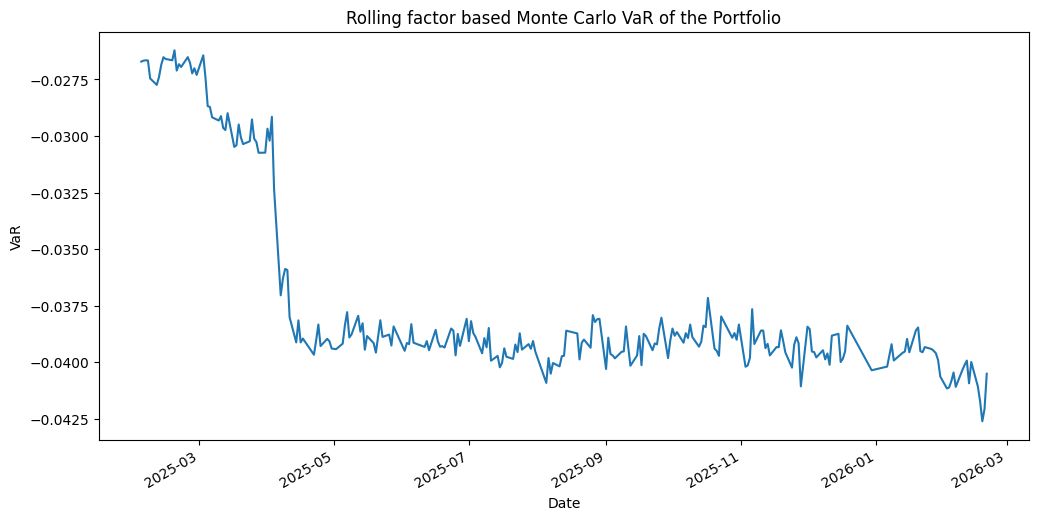

In [67]:
rolling_var.plot(title="Rolling factor based Monte Carlo VaR of the Portfolio", figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("VaR")
plt.show()

In [ ]:
# BACKTESTING FUNCTION (BASEL TRAFFIC LIGHT APPROACH)
def backtest_VaR(real_returns, VaR):
    """
    Backtest VaR: support both static (single value) and rolling (Series) VaR.

    Parameters:
        real_returns (pd.Series): Actual portfolio returns.
        VaR (pd.Series): rolling VaR series.

    Returns:
        dict: violations, total, rate, zone
    """
    if not isinstance(real_returns, pd.Series):
        real_returns = pd.Series(real_returns)

    # Case 1: Rolling VaR (Series)
    if isinstance(VaR, pd.Series):
        real_returns, VaR = real_returns.align(VaR, join='inner')  # ensure alignment
        violations = real_returns < VaR

    num_violations = violations.sum()
    total_days = len(real_returns)
    violation_rate = num_violations / total_days

    # Basel traffic light zones
    if num_violations <= 4:
        zone = "Green"
    elif num_violations <= 9:
        zone = "Yellow"
    else:
        zone = "Red"

    return {
        "violations": int(num_violations),
        "total": total_days,
        "rate": violation_rate,
        "zone": zone
    }

In [69]:
test_start = config["test_start"]
test_end = config["test_end"]

test_prices = get_price_data(tickers, test_start, test_end)
test_returns = calculate_log_returns(test_prices)
test_P_returns = test_returns[tickers]  
test_P_return = test_P_returns @ weights

In [ ]:
# Align backtest returns and rolling VaR
aligned_index = rolling_var.index.intersection(test_P_return.index)

rolling_var = rolling_var.loc[aligned_index]
test_P_return_aligned = test_P_return.loc[aligned_index]

x = test_P_return.loc[rolling_var.index].index
y = test_P_return.loc[rolling_var.index].values.astype("float64")
y2 = rolling_var.values
mask = y < y2

backtest_VaR(test_P_return , rolling_var)

{'violations': 5, 'total': 250, 'rate': np.float64(0.02), 'zone': 'Yellow'}

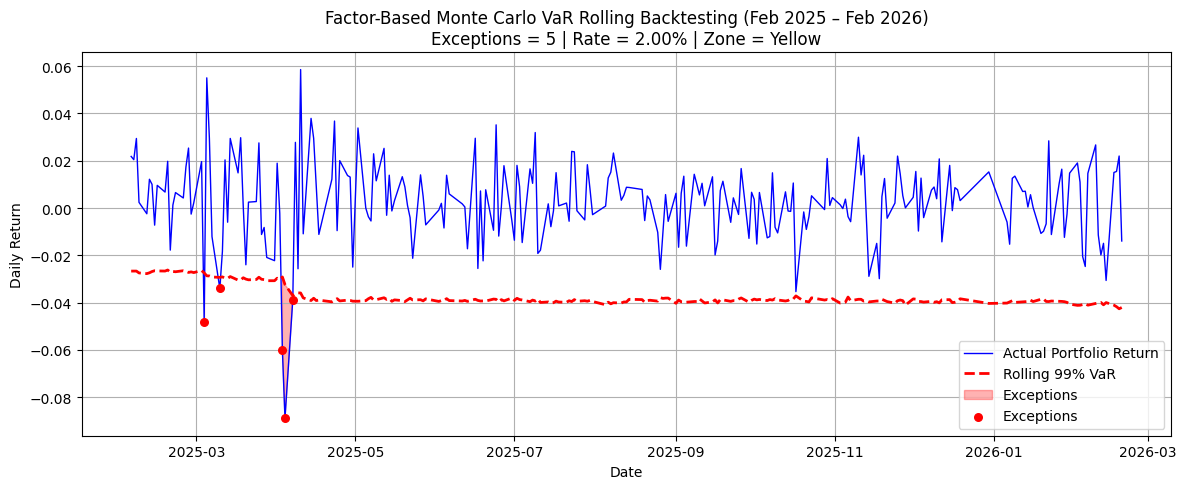

In [ ]:
# Backtest rolling VaR and visualize results
result = backtest_VaR(test_P_return, rolling_var)


plt.figure(figsize=(12, 5))
plt.plot(x, y, label="Actual Portfolio Return", color="blue", linewidth=1)
plt.plot(x, y2, color="red", linestyle="--", linewidth=2, label="Rolling 99% VaR")
plt.fill_between(x, y, y2, where=mask, color='red', alpha=0.3, label="Exceptions")
plt.scatter(x[mask], y[mask], color='red', s=30, label="Exceptions", zorder=5)
plt.title(f"Factor-Based Monte Carlo VaR Rolling Backtesting (Feb 2025 – Feb 2026)\n"
          f"Exceptions = {result['violations']} | "
          f"Rate = {result['rate']:.2%} | Zone = {result['zone']}")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Factor-Based Monte Carlo VaR Rolling Backtesting.png", dpi=300, bbox_inches='tight')
plt.show()

### Historical Stress Var (Hist SVaR)
According to (European Banking Authority, 2012), risk factors that used in the VaR model should also be used in SVaR. If for particular reasons, the risk factors are not used the same, similar risk factors can be used to test, as long as they are still relevant.
Upon performing the model, the author figured out that when changing the data input period, the linear relationships between risk factors and portfolio return might not be the same. 

Therefore, for Hist SVaR, risk factors will be tested to check the linear relationship again.

In [ ]:

Price_stress = get_price_data(All_Tickers, train_start_stress, train_end_stress)
Log_R_stress = calculate_log_returns(Price_stress)

In [ ]:
# Perform regression on stress period data to get new betas
Portfolio_R_stress = Log_R_stress[tickers]  
PortfolioReturn_stress = Portfolio_R_stress @ weights #y

Factor_R_stress = Log_R_stress[Factor_Tickers]  #x 

In [74]:
def RunOLSRegression(PortfolioReturn_stress: pd.Series,
                     FactorReturns_1: pd.DataFrame) -> pd.DataFrame:
    df = pd.concat([PortfolioReturn_stress, FactorReturns_1], axis=1).dropna() 

    X_stress = sm.add_constant(FactorReturns_1)
    y_stress = PortfolioReturn_stress

    model_stress = sm.OLS(y_stress, X_stress).fit()

    result_df = pd.DataFrame({
        'Factor': model_stress.params.index,
        'Beta': model_stress.params.values,
        'T-Stat': model_stress.tvalues.values,
        'P-Value': model_stress.pvalues.values
    })

    result_df = result_df[result_df['Factor'] != 'const']
    result_df['P-Value'] = result_df['P-Value'].round(4)
    result_df = result_df[['Factor', 'Beta', 'T-Stat', 'P-Value']]

    return result_df

In [75]:
def GetPortR_Square(PortfolioReturn_stress: pd.DataFrame,
                    FactorReturns_1: pd.DataFrame) -> tuple[float, float]:

    X1 = sm.add_constant(FactorReturns_1)
    y1 = PortfolioReturn_stress
    Model_1 = sm.OLS(y1, X1).fit()
    return Model_1.rsquared.round(2), Model_1.rsquared_adj.round(2)

In [76]:
GetPortR_Square(PortfolioReturn_stress, Factor_R_stress)

(np.float64(0.92), np.float64(0.92))

In [77]:
regression_result_1 = RunOLSRegression(PortfolioReturn_stress, Factor_R_stress)
print(regression_result_1)

    Factor      Beta     T-Stat  P-Value
1   ^STOXX -0.261486  -3.859800   0.0001
2  EXV1.DE  1.302623  34.034694   0.0000
3  IEAC.MI  0.140852   0.931244   0.3526
4  IPRP.SW  0.044839   1.509617   0.1324
5  IBGL.AS -0.053316  -1.025067   0.3063


In [78]:
FactorR_stress = Factor_R_stress.drop(columns=["IEAC.MI","IPRP.SW","IBGL.AS"]) 

In [79]:
regression_result_2 = RunOLSRegression(PortfolioReturn_stress, FactorR_stress)
print(regression_result_2)

    Factor      Beta     T-Stat  P-Value
1   ^STOXX -0.195599  -3.540032   0.0005
2  EXV1.DE  1.303837  35.724964   0.0000


In [80]:
def CalculateVIF(FactorReturns_1: pd.DataFrame) -> pd.DataFrame:

    vif_data_1 = pd.DataFrame()
    vif_data_1["Factor"] = FactorReturns_1.columns
    vif_data_1["VIF"] = [variance_inflation_factor(FactorReturns_1.values, i)
                          for i in range(FactorReturns_1.shape[1])]
    return vif_data_1   

In [81]:
VIF_result_1 = CalculateVIF(FactorR_stress)
VIF_result_1

,Factor,VIF
0,^STOXX,2.707568
1,EXV1.DE,2.707568


In [82]:
def SimulateFactors(FactorReturns_1: pd.DataFrame, NSim: int = 10000):
    """
    Simulate multivariate normal factor returns based on historical covariance and mean.
    """
    assert isinstance(NSim, int), "NSim must be an integer"

    FactorCov = FactorReturns_1.cov().values
    FactorMean = FactorReturns_1.mean().values
    Simulated = np.random.multivariate_normal(mean=FactorMean, cov=FactorCov, size=NSim)

    return pd.DataFrame(Simulated, columns=FactorReturns_1.columns)

In [ ]:
# Run Monte Carlo simulation for stress test VaR
model_stress = sm.OLS(PortfolioReturn_stress, sm.add_constant(FactorR_stress)).fit()
PortfolioBeta_stress = model_stress.params.drop("const")

Simulated_Factor_DF_stress = SimulateFactors(FactorR_stress, 10000)[PortfolioBeta_stress.index]
SimulatedPortfolioReturn_stress = Simulated_Factor_DF_stress @ PortfolioBeta_stress.values
PortfolioBeta_stress.index

Index(['^STOXX', 'EXV1.DE'], dtype='object')

-> Surviving factors: Market risk + Financial risk

In [84]:
SimulatedPortfolioReturn_stress

0       0.024776
1      -0.022525
2       0.006361
3       0.007376
4      -0.005927
          ...   
9995   -0.038359
9996   -0.006785
9997   -0.011572
9998    0.000384
9999   -0.008677
Length: 10000, dtype: float64

In [ ]:
# Calculate 99% historical SVaR 
SVaR = (np.percentile(SimulatedPortfolioReturn_stress, (1 - confidence) * 100))
print(f"1-day {int(confidence*100)}% Historical SVaR (fixed 2022 crisis window): {SVaR:.2%}")

1-day 99% Historical SVaR (fixed 2022 crisis window): -5.13%


In [ ]:
# Though not officially required, we can still backtest the historical SVaR against the test period returns to see how it performs. Please note that this is not a standard practice, as the historical SVaR is based on a fixed stress period and does not change over time like the rolling VaR, but it can still provide some insights into how well the historical SVaR captures extreme losses during the test period.
SVaR_series = pd.Series(SVaR, index=test_P_return.index)
test_P_return_250 = test_P_return.iloc[-250:]
backtest_VaR(test_P_return_250, SVaR_series)

{'violations': 2, 'total': 250, 'rate': np.float64(0.008), 'zone': 'Green'}

### Hypothetical SVaR
According to (European Banking Authority, 2012), risk factors that used in the VaR model should also be used in SVaR. Since Hypothetical SVaR use the same data input period as normal VaR, the same risk factors used in Normal VaR will be used in this Hyp SVaR, which is financial risk (ticker 'EXV1.DE') and credit risk ('IEAC.MI')

In [87]:
print(Log_R_normal[['EXV1.DE', 'IEAC.MI']].describe())

Ticker     EXV1.DE     IEAC.MI
count   254.000000  254.000000
mean      0.001732    0.000237
std       0.009525    0.001979
min      -0.026473   -0.004780
25%      -0.003412   -0.001167
50%       0.002524    0.000297
75%       0.008166    0.001688
max       0.028286    0.006584


For hypothetical SVaR, risk factors need to be deviated higher than normal conditions. However, there is no official document state as how much higher it should be. Accoding to Kupiec (cited as in Tan & Chan, 2023), deviation can be around 3.5x.
Therefore, deviations of betas of this model will be multiplier of 4

In [88]:
0.009569 * 4

0.038276

In [89]:
0.002002 * 4

0.008008

In [ ]:
# Define extreme shocks for the two significant factors based on 4 times their daily standard deviation (very extreme loss scenario)
stress_shock = {
    "EXV1.DE": -0.038,   # ≈ -4.0 × daily std (very extreme loss)
    "IEAC.MI": -0.008    # ≈ -4.0 × daily std (very extreme loss)
}

# Simulate stressed factors (mean shifted, covariance unchanged)
FactorCov = Factor_R.cov().values
FactorMean = Factor_R.mean().values

# Build shock vector aligned with columns
shock_vector = np.array([stress_shock.get(col, 0) for col in Factor_R.columns])

# Stressed mean = original mean + extreme shock
stressed_mean = FactorMean + shock_vector

# Simulate 10,000 scenarios
Simulated_Factor_DF_stress_hyp = pd.DataFrame(
    np.random.multivariate_normal(
        mean=stressed_mean,
        cov=FactorCov,
        size=10000
    ),
    columns=Factor_R.columns
)

# Map to portfolio using existing betas 
SimulatedPortfolioReturn_hyp = Simulated_Factor_DF_stress_hyp[PortfolioBeta.index] @ PortfolioBeta.values

# Hypothetical SVaR
SVaR_hypo = (np.percentile(SimulatedPortfolioReturn_hyp, (1 - confidence) * 100))

print(f"Hypothetical SVaR (extreme mean shock only): {SVaR_hypo:.2%}")
 

Hypothetical SVaR (extreme mean shock only): -6.67%


In [ ]:
# Backtest hypothetical SVaR against test period returns (not standard practice, but for insight)
SVaR_hypo_series = pd.Series(SVaR_hypo, index=test_P_return.index)
test_P_return_250 = test_P_return.iloc[-250:]
backtest_VaR(test_P_return_250, SVaR_hypo_series)

{'violations': 1, 'total': 250, 'rate': np.float64(0.004), 'zone': 'Green'}

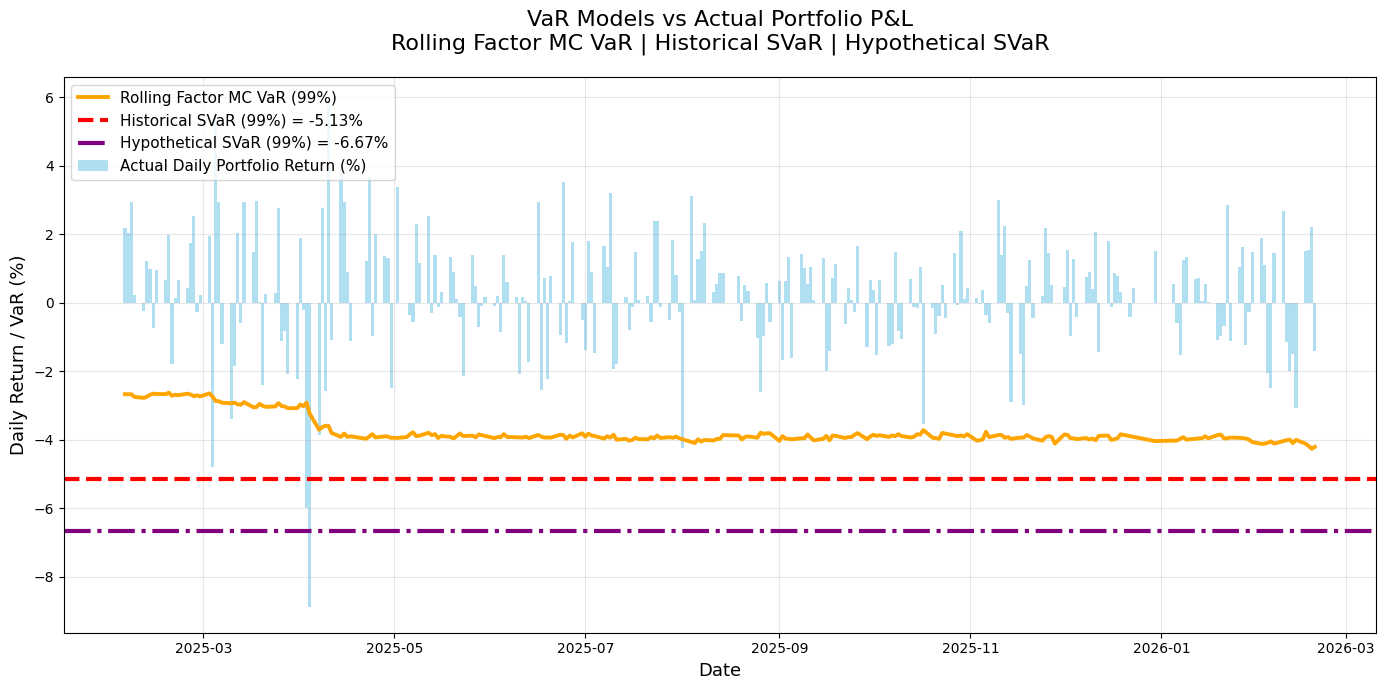


=== VaR MODEL COMPARISON TABLE ===
                   Model  Min (%)  Max (%)  Mean (%)  Std (%)  \
0  Rolling Factor MC VaR   -4.260   -2.621    -3.733    0.425   
1        Historical SVaR   -5.134   -5.134    -5.134    0.000   
2      Hypothetical SVaR   -6.672   -6.672    -6.672    0.000   

  Hist SVaR / rolling VaR ratio  Hypo SVaR / rolling VaR ratio  
0                          1.38x                         1.79x  
1                                                               
2                                                               


In [ ]:
# Visualize all three models with actual portfolio returns for the test period
# Actual daily P&L on test period
actual_port_return = test_P_return.loc[config["test_start"]:config["test_end"]]

# ===================================================================
# 2. Professional Comparison Plot
# ===================================================================
fig, ax = plt.subplots(figsize=(14, 7))

# Actual P&L (bars)
ax.bar(actual_port_return.index, actual_port_return * 100,
       color='skyblue', alpha=0.65, width=1, label='Actual Daily Portfolio Return (%)')

# Rolling Normal VaR (MC factor model)
ax.plot(rolling_var.index, rolling_var * 100,
        color='orange', linewidth=2.8, label='Rolling Factor MC VaR (99%)')

# Historical SVaR (horizontal dashed)
ax.axhline(y=SVaR * 100, color='red', linestyle='--', linewidth=3,
           label=f'Historical SVaR (99%) = {SVaR:.2%}')

# Hypothetical SVaR (horizontal dash-dot)
ax.axhline(y=SVaR_hypo * 100, color='purple', linestyle='-.', linewidth=3,
           label=f'Hypothetical SVaR (99%) = {SVaR_hypo:.2%}')

# Formatting
ax.set_title('VaR Models vs Actual Portfolio P&L\n'
             'Rolling Factor MC VaR | Historical SVaR | Hypothetical SVaR',
             fontsize=16, pad=20)
ax.set_ylabel('Daily Return / VaR (%)', fontsize=13)
ax.set_xlabel('Date', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left')


plt.tight_layout()

# Save high-resolution figure for
plt.savefig("VaR_Comparison_Rolling_Historical_Hypothetical.png", dpi=400, bbox_inches='tight')
plt.show()

# ===================================================================
# 3. Summary Table
# ===================================================================
summary_table = pd.DataFrame({
    "Model": ["Rolling Factor MC VaR", "Historical SVaR", "Hypothetical SVaR"],
    "Min (%)":   [rolling_var.min()*100, SVaR*100, SVaR_hypo*100],
    "Max (%)":   [rolling_var.max()*100, SVaR*100, SVaR_hypo*100],
    "Mean (%)":  [rolling_var.mean()*100, SVaR*100, SVaR_hypo*100],
    "Std (%)":   [rolling_var.std()*100, 0.0, 0.0],
    "Hist SVaR / rolling VaR ratio ":    [f"{SVaR / rolling_var.mean():.2f}x", "", ""],
    "Hypo SVaR / rolling VaR ratio":    [f"{SVaR_hypo / rolling_var.mean():.2f}x", "", ""]
}).round(3)

print("\n=== VaR MODEL COMPARISON TABLE ===")
print(summary_table)